In [1]:
# ── Notebook 04 — EDA ───────────────────────────────────────────────────────
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

REPO_ROOT   = Path().resolve().parents[1]
CLEAN_DIR   = REPO_ROOT / "Data" / "Clean"
REPORTS_DIR = REPO_ROOT / "Reports" / "EDA-Fantasy"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

with open(CLEAN_DIR / "merged_non_western_fantasy.json") as f:
    df = pd.DataFrame(json.load(f))
print(f"Loaded: {len(df):,} books")

# Style
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

print(f"── Dataset Overview ──")
print(f"  Total books:       {len(df):,}")
print(f"  Unique authors:    {df['author'].nunique():,}")
print(f"  Sources:           {df['source'].value_counts().to_dict()}")
print(f"  Year range:        {df['year_published'].min()} – {df['year_published'].max()}")
print(f"  Avg rating range:  {df['avg_rating'].min()} – {df['avg_rating'].max()}")
print(f"\n── Source tag breakdown ──")
print(df["source_tag"].value_counts().to_string())

Loaded: 3,229 books
── Dataset Overview ──
  Total books:       3,229
  Unique authors:    2,197
  Sources:           {'goodreads': 1898, 'open_library': 1331}
  Year range:        1592.0 – 2027.0
  Avg rating range:  0.0 – 5.0

── Source tag breakdown ──
source_tag
asian-fantasy              859
afrofuturism               699
africa                     346
south_asian                254
chinese                    231
japanese                   214
african-fantasy            210
middle_eastern              88
latin_american              69
middle-eastern-fantasy      54
australian-fantasy          37
indigenous-fantasy          30
asian-science-fiction       20
korean                      17
latin-american-fantasy      15
southeast_asian             14
filipino                    12
wuxia                       11
anansi                       9
indigenous_americas          9
oceania                      9
south-american-fantasy       7
xianxia                      6
orisha              

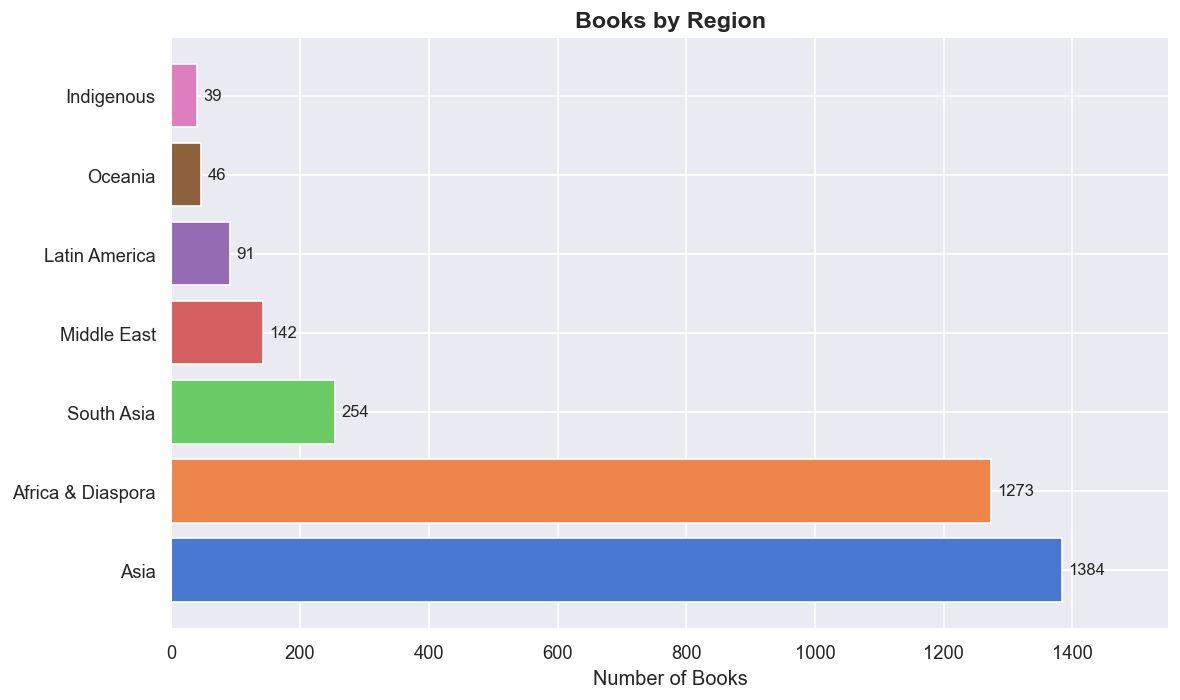

✅ Chart 1 saved


In [2]:
# ── Chart 1 — Books by region ───────────────────────────────────────────────

# Consolidate source_tags into clean regions
REGION_MAP = {
    "asian-fantasy":           "Asia",
    "japanese":                "Asia",
    "chinese":                 "Asia",
    "korean":                  "Asia",
    "wuxia":                   "Asia",
    "xianxia":                 "Asia",
    "southeast_asian":         "Asia",
    "filipino":                "Asia",
    "asian-science-fiction":   "Asia",
    "afrofuturism":            "Africa & Diaspora",
    "africa":                  "Africa & Diaspora",
    "african-fantasy":         "Africa & Diaspora",
    "african-science-fiction": "Africa & Diaspora",
    "afrofuturism":            "Africa & Diaspora",
    "anansi":                  "Africa & Diaspora",
    "orisha":                  "Africa & Diaspora",
    "igbo":                    "Africa & Diaspora",
    "zulu":                    "Africa & Diaspora",
    "akan":                    "Africa & Diaspora",
    "yoruba":                  "Africa & Diaspora",
    "south_asian":             "South Asia",
    "middle_eastern":          "Middle East",
    "middle-eastern-fantasy":  "Middle East",
    "latin_american":          "Latin America",
    "latin-american-fantasy":  "Latin America",
    "south-american-fantasy":  "Latin America",
    "indigenous_americas":     "Indigenous",
    "indigenous-fantasy":      "Indigenous",
    "oceania":                 "Oceania",
    "australian-fantasy":      "Oceania",
}

df["region"] = df["source_tag"].map(REGION_MAP).fillna("Other")

region_counts = df["region"].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(region_counts.index, region_counts.values, color=sns.color_palette("muted", len(region_counts)))
ax.bar_label(bars, padding=4, fontsize=10)
ax.set_xlabel("Number of Books")
ax.set_title("Books by Region", fontsize=14, fontweight="bold")
ax.set_xlim(0, region_counts.max() * 1.12)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "01_books_by_region.png")
plt.show()
print("✅ Chart 1 saved")

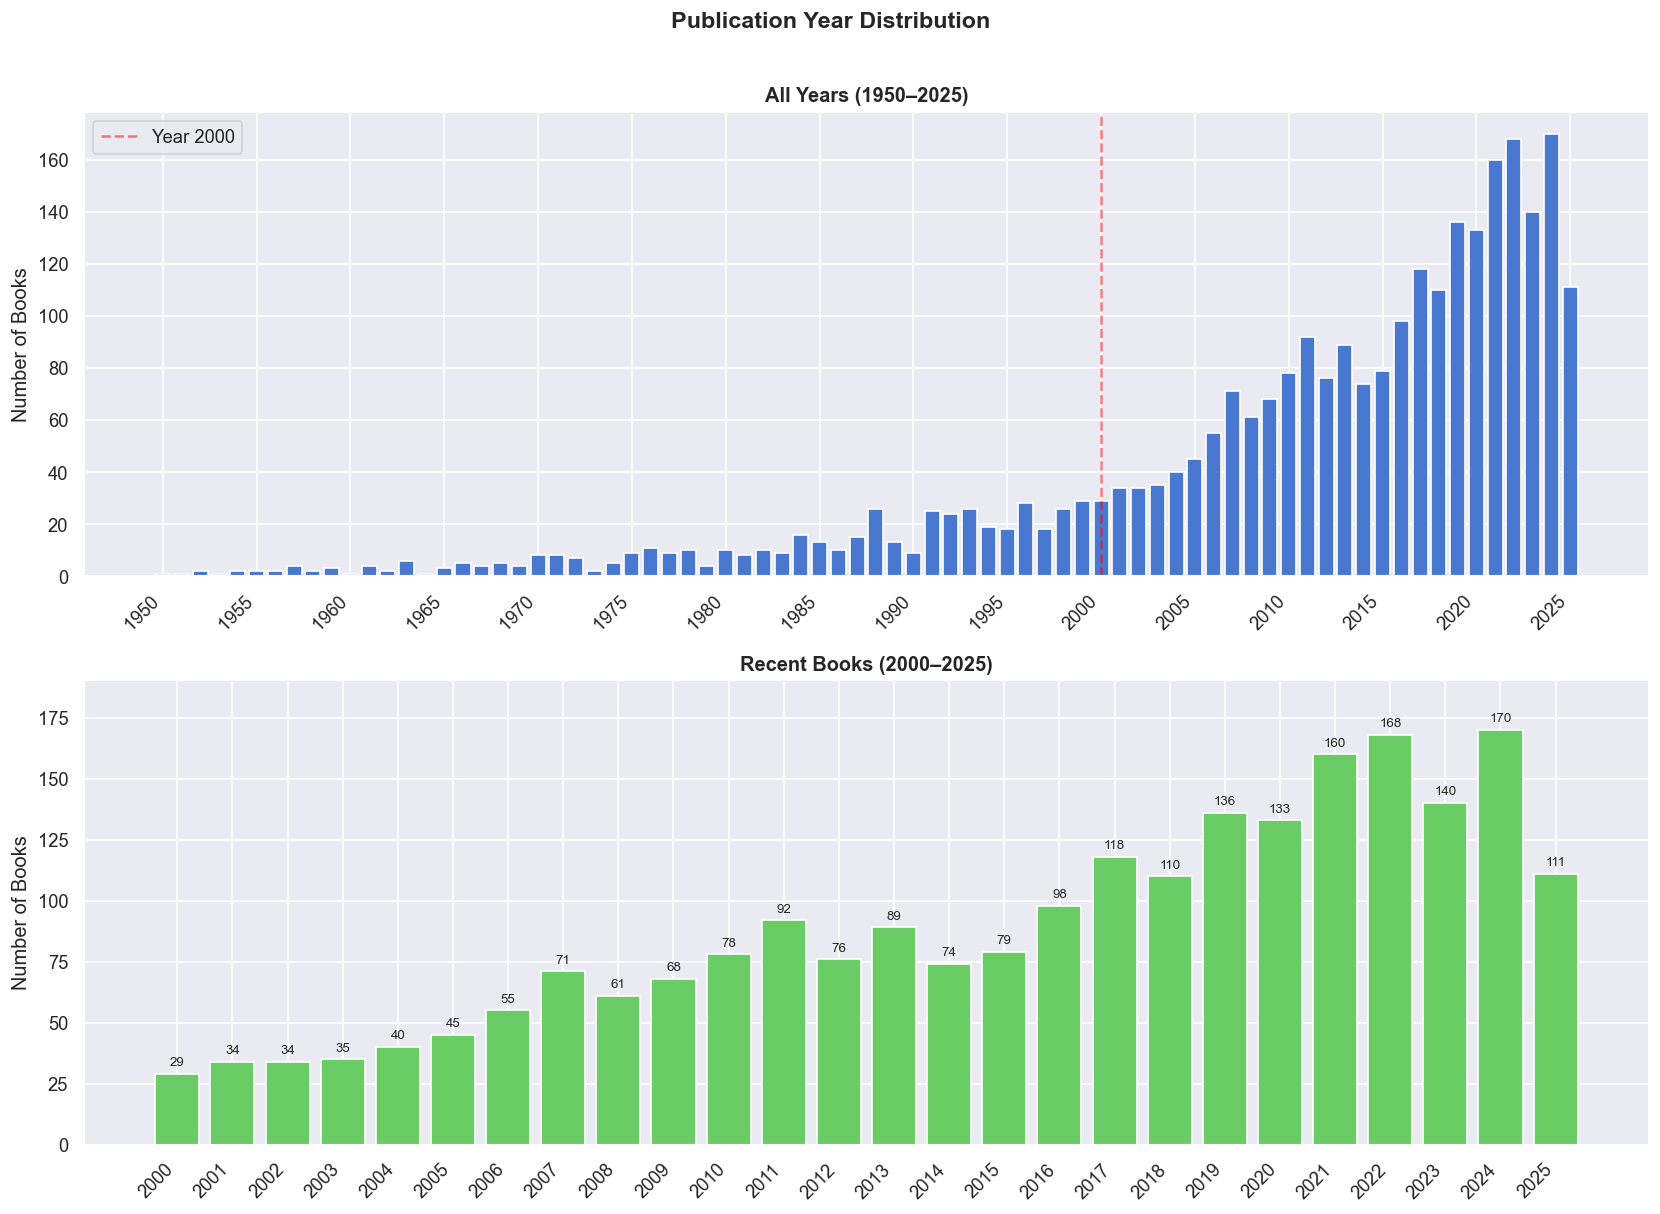

✅ Chart 2 saved


In [3]:
# ── Chart 2 — Fixed: no .0, both time periods ───────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# ── Panel 1: 1950–2025 ─────────────────────────────────────────────────────
year_all = df[(df["year_published"] >= 1950) & (df["year_published"] <= 2025)]
counts_all = year_all["year_published"].value_counts().sort_index()

ax1.bar(counts_all.index, counts_all.values,
        color=sns.color_palette("muted")[0], edgecolor="white", width=0.8)
ax1.axvline(x=2000, color="red", linestyle="--", alpha=0.5, label="Year 2000")
ax1.set_xticks(range(1950, 2026, 5))
ax1.set_xticklabels(range(1950, 2026, 5), rotation=45, ha="right")
ax1.set_ylabel("Number of Books")
ax1.set_title("All Years (1950–2025)", fontsize=12, fontweight="bold")
ax1.legend()

# ── Panel 2: 2000–2025 zoomed with labels ──────────────────────────────────
year_recent = df[(df["year_published"] >= 2000) & (df["year_published"] <= 2025)]
counts_recent = year_recent["year_published"].value_counts().sort_index()

# Fix the .0 — convert to int for display
counts_recent.index = counts_recent.index.astype(int)

bars = ax2.bar(counts_recent.index, counts_recent.values,
               color=sns.color_palette("muted")[2], edgecolor="white", width=0.8)
ax2.bar_label(bars, padding=3, fontsize=8)
ax2.set_xticks(counts_recent.index)
ax2.set_xticklabels(counts_recent.index.astype(int), rotation=45, ha="right")
ax2.set_ylabel("Number of Books")
ax2.set_title("Recent Books (2000–2025)", fontsize=12, fontweight="bold")
ax2.set_ylim(0, counts_recent.max() * 1.12)

fig.suptitle("Publication Year Distribution", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "02_publication_years.png", bbox_inches="tight")
plt.show()
print("✅ Chart 2 saved")

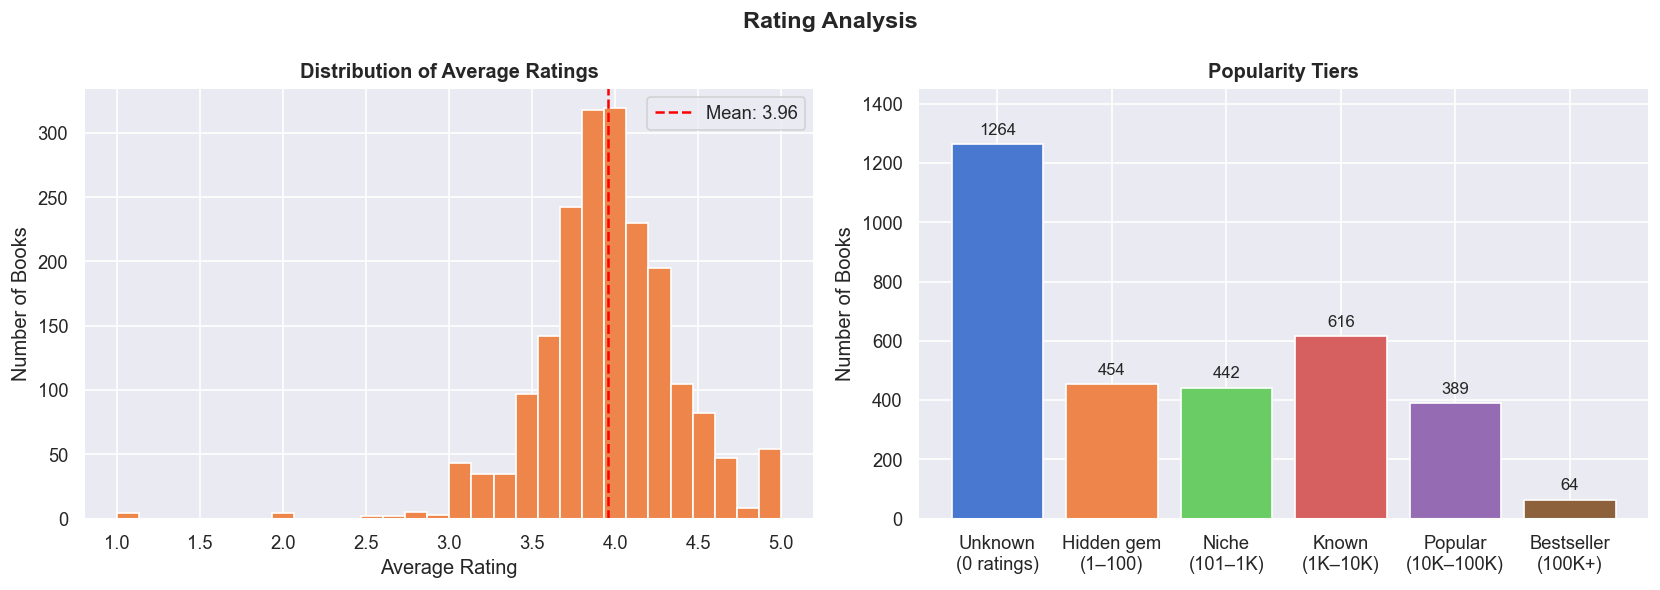

In [4]:
# ── Chart 3 — Fixed right panel: popularity tiers ──────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: histogram of avg ratings (same as before) ───────────────────────
rated = df[df["avg_rating"] > 0].copy()
ax1.hist(rated["avg_rating"], bins=30,
         color=sns.color_palette("muted")[1], edgecolor="white")
ax1.set_xlabel("Average Rating")
ax1.set_ylabel("Number of Books")
ax1.set_title("Distribution of Average Ratings", fontsize=12, fontweight="bold")
ax1.axvline(rated["avg_rating"].mean(), color="red", linestyle="--",
            label=f"Mean: {rated['avg_rating'].mean():.2f}")
ax1.legend()

# ── Right: popularity tiers as bar chart ──────────────────────────────────
has_ratings = df[df["num_ratings"] > 0].copy()

tiers = {
    "Unknown\n(0 ratings)":      (df["num_ratings"] == 0).sum(),
    "Hidden gem\n(1–100)":       ((has_ratings["num_ratings"] >= 1)   & (has_ratings["num_ratings"] <= 100)).sum(),
    "Niche\n(101–1K)":           ((has_ratings["num_ratings"] > 100)  & (has_ratings["num_ratings"] <= 1000)).sum(),
    "Known\n(1K–10K)":           ((has_ratings["num_ratings"] > 1000) & (has_ratings["num_ratings"] <= 10000)).sum(),
    "Popular\n(10K–100K)":       ((has_ratings["num_ratings"] > 10000) & (has_ratings["num_ratings"] <= 100000)).sum(),
    "Bestseller\n(100K+)":       (has_ratings["num_ratings"] > 100000).sum(),
}

colors = sns.color_palette("muted", len(tiers))
bars = ax2.bar(tiers.keys(), tiers.values(), color=colors, edgecolor="white")
ax2.bar_label(bars, padding=4, fontsize=10)
ax2.set_ylabel("Number of Books")
ax2.set_title("Popularity Tiers", fontsize=12, fontweight="bold")
ax2.set_ylim(0, max(tiers.values()) * 1.15)

plt.suptitle("Rating Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "03_ratings.png", bbox_inches="tight")
plt.show()

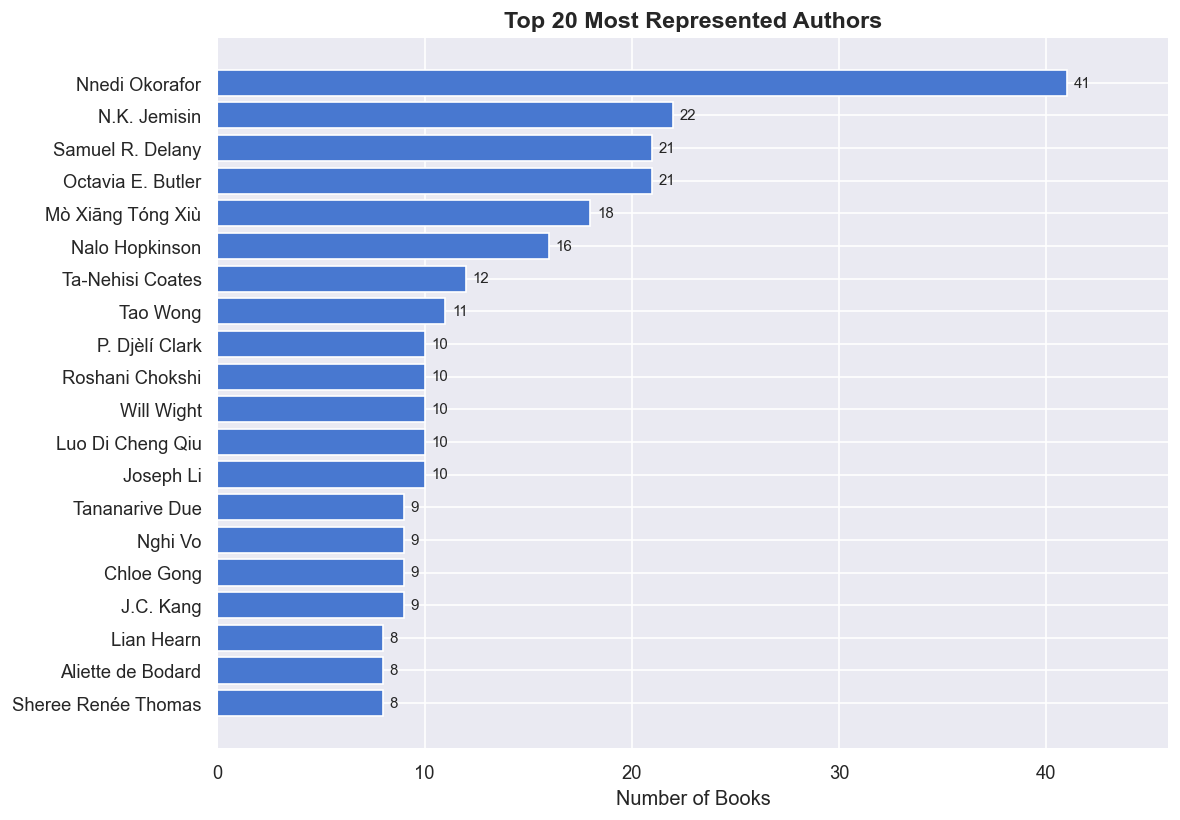

✅ Chart 4 saved


In [5]:
# ── Chart 4 — Top 20 most represented authors ───────────────────────────────
top_authors = df["author"].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top_authors.index[::-1], top_authors.values[::-1],
               color=sns.color_palette("muted")[0], edgecolor="white")
ax.bar_label(bars, padding=4, fontsize=9)
ax.set_xlabel("Number of Books")
ax.set_title("Top 20 Most Represented Authors", fontsize=14, fontweight="bold")
ax.set_xlim(0, top_authors.max() * 1.12)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "04_top_authors.png")
plt.show()
print("✅ Chart 4 saved")

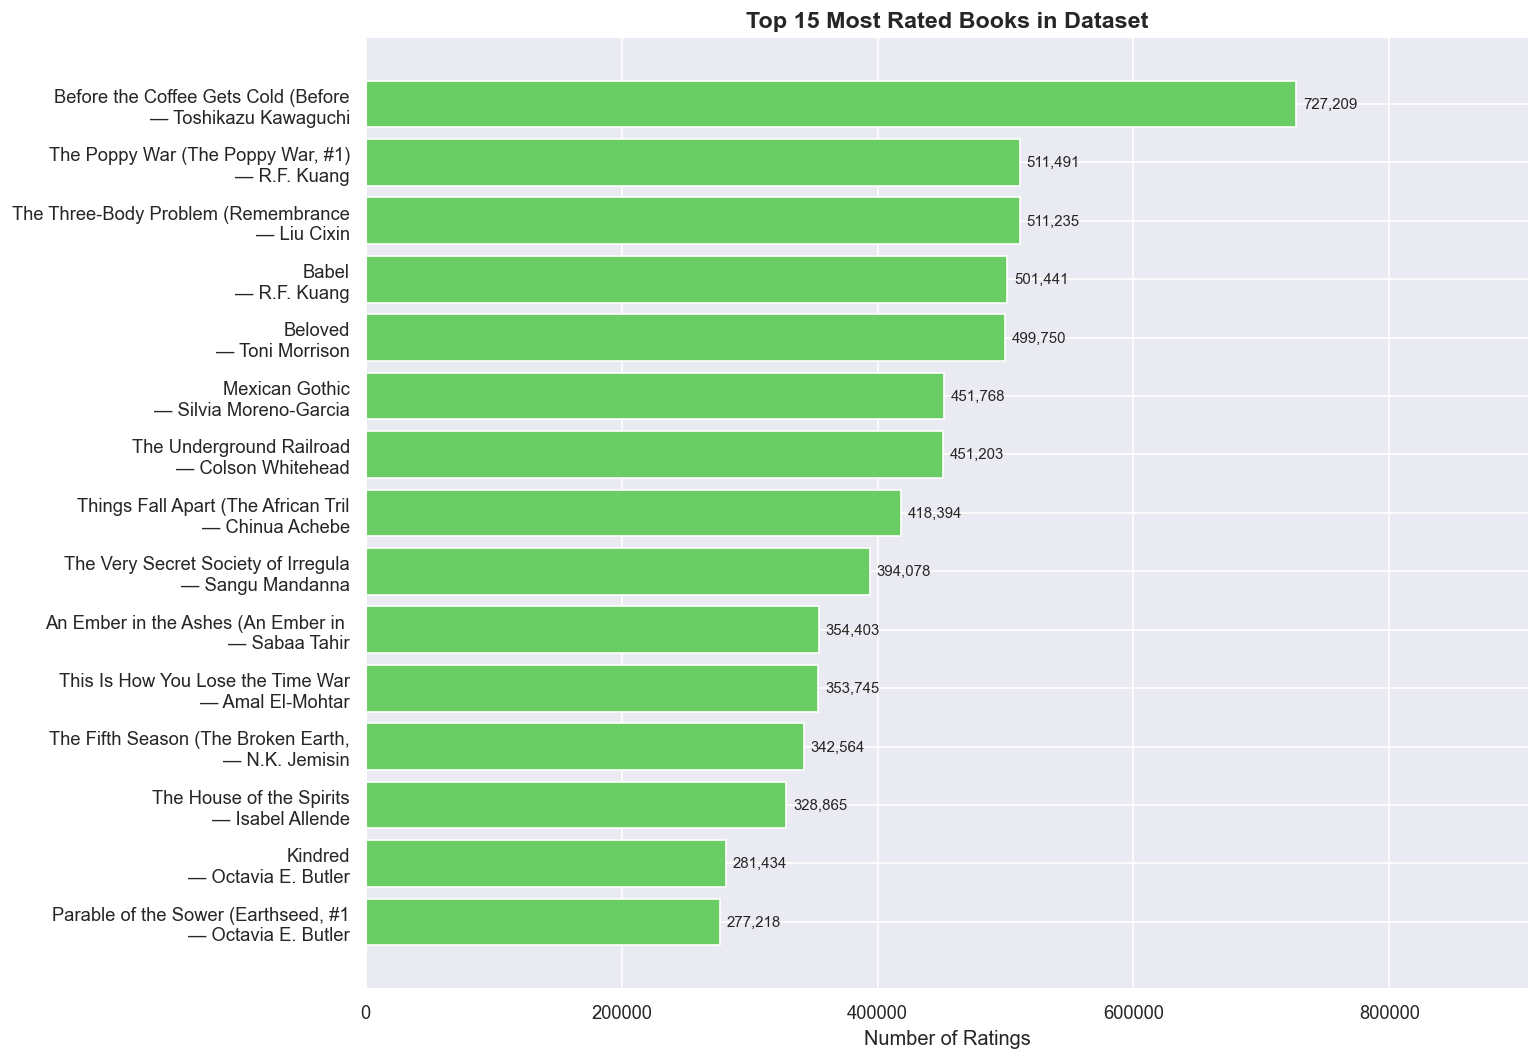

Empty DataFrame
Columns: [title, author, source_tag]
Index: []
Empty DataFrame
Columns: [title, author, source_tag]
Index: []


In [6]:
# ── Chart 5 — Fixed author names ───────────────────────────────────────────
top_rated = df[df["num_ratings"] > 0].nlargest(15, "num_ratings")
labels    = top_rated["title"].str[:35] + "\n— " + top_rated["author"]

fig, ax = plt.subplots(figsize=(13, 9))
bars = ax.barh(labels.values[::-1], top_rated["num_ratings"].values[::-1],
               color=sns.color_palette("muted")[2], edgecolor="white")
ax.bar_label(bars, labels=[f"{v:,}" for v in top_rated["num_ratings"].values[::-1]],
             padding=4, fontsize=9)
ax.set_xlabel("Number of Ratings")
ax.set_title("Top 15 Most Rated Books in Dataset", fontsize=14, fontweight="bold")
ax.set_xlim(0, top_rated["num_ratings"].max() * 1.25)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "05_most_rated.png")
plt.show()

# Check Snow Crash and When the Moon Hatched
for t in ["Snow Crash", "When the Moon Hatched"]:
    found = df[df["title"].str.contains(t, case=False, na=False)][["title","author","source_tag"]]
    print(found.to_string())

In [7]:
print(f"Final dataset: {len(df):,} books")

Final dataset: 3,229 books


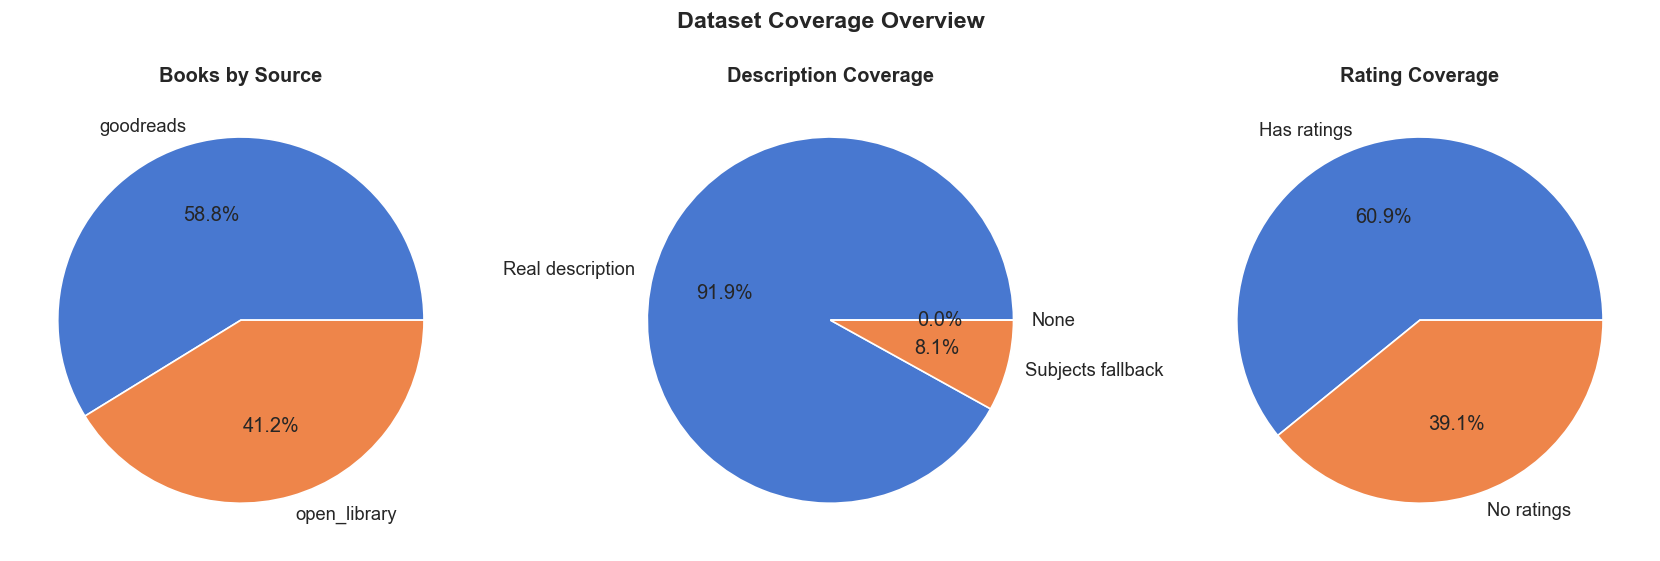

✅ Chart 6 saved


In [8]:
# ── Chart 6 — Coverage heatmap ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# ── Panel 1: Source breakdown ──────────────────────────────────────────────
source_counts = df["source"].value_counts()
axes[0].pie(source_counts.values, labels=source_counts.index, 
            autopct='%1.1f%%', colors=sns.color_palette("muted", 2))
axes[0].set_title("Books by Source", fontweight="bold")

# ── Panel 2: Description coverage ─────────────────────────────────────────
has_real_desc = df["description"].apply(
    lambda x: bool(str(x).strip()) and 
    str(x).strip() != "nan" and 
    "A work of fantasy fiction involving" not in str(x)
).sum()
has_fallback = df["description"].apply(
    lambda x: "A work of fantasy fiction involving" in str(x)
).sum()
has_none = len(df) - has_real_desc - has_fallback

axes[1].pie(
    [has_real_desc, has_fallback, has_none],
    labels=["Real description", "Subjects fallback", "None"],
    autopct='%1.1f%%',
    colors=sns.color_palette("muted", 3)
)
axes[1].set_title("Description Coverage", fontweight="bold")

# ── Panel 3: Rating coverage ───────────────────────────────────────────────
has_rating  = (df["num_ratings"] > 0).sum()
no_rating   = (df["num_ratings"] == 0).sum()
axes[2].pie(
    [has_rating, no_rating],
    labels=["Has ratings", "No ratings"],
    autopct='%1.1f%%',
    colors=sns.color_palette("muted", 2)
)
axes[2].set_title("Rating Coverage", fontweight="bold")

plt.suptitle("Dataset Coverage Overview", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "06_coverage.png")
plt.show()
print("✅ Chart 6 saved")

In [9]:
# ── region_stats for Chart 7 ─────────────────────────────────────────────────
df["region"] = df["source_tag"].map(REGION_MAP).fillna("Other")

rated_df = df[df["avg_rating"] > 0]

region_stats = (
    rated_df.groupby("region")["avg_rating"]
    .agg(avg_rating="mean", count="count")
    .sort_values("avg_rating", ascending=False)
)
print(region_stats)

                   avg_rating  count
region                              
Asia                 3.965145    929
Africa & Diaspora    3.956768    826
Middle East          3.929403     67
Oceania              3.926857     35
Latin America        3.921613     31
Indigenous           3.914444     27
South Asia           3.877895     57


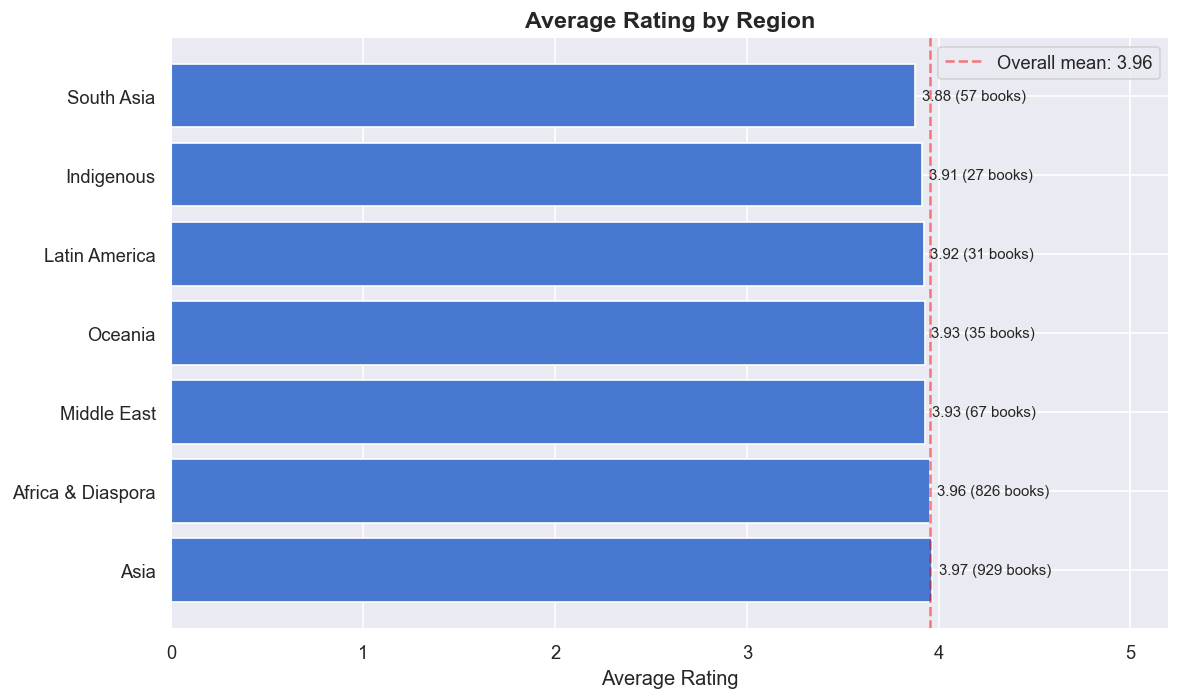

✅ Chart 7 saved — NB04 complete! 🎉


In [10]:
# ── Chart 7 — Fixed: same color ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(region_stats.index, region_stats["avg_rating"],
               color=sns.color_palette("muted")[0], edgecolor="white")
ax.bar_label(bars, labels=[f"{v:.2f} ({region_stats['count'][i]:,} books)" 
                            for i, v in zip(region_stats.index, region_stats["avg_rating"])],
             padding=4, fontsize=9)
ax.set_xlabel("Average Rating")
ax.set_title("Average Rating by Region", fontsize=14, fontweight="bold")
ax.set_xlim(0, 5.2)
ax.axvline(x=rated_df["avg_rating"].mean(), color="red", linestyle="--", 
           alpha=0.5, label=f"Overall mean: {rated_df['avg_rating'].mean():.2f}")
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / "07_rating_by_region.png")
plt.show()
print("✅ Chart 7 saved — NB04 complete! 🎉")

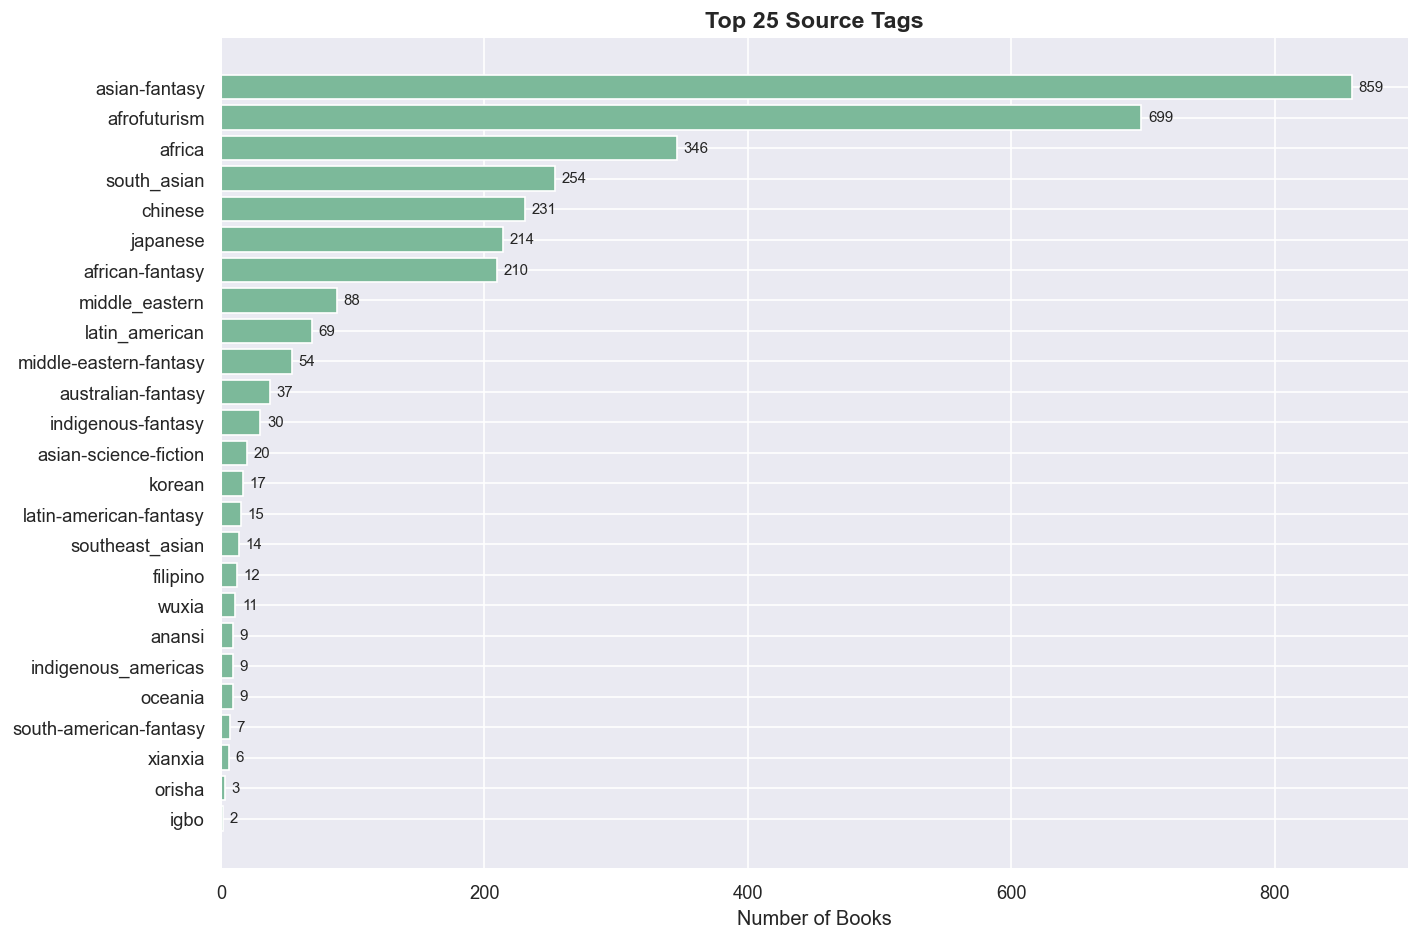

✅ Chart 8 saved


In [11]:
# ── Chart 8 — Top 25 source tags ───────────────────────────────────────────
tag_counts = df["source_tag"].value_counts().head(25)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(tag_counts.index[::-1], tag_counts.values[::-1], color="#7CB99A")
ax.set_title("Top 25 Source Tags", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Books")

for bar, val in zip(bars, tag_counts.values[::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=9)

plt.tight_layout()
plt.savefig(REPORTS_DIR / "08_top_tags.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 8 saved")

In [49]:
# ── Install extra dependencies ───────────────────────────────────────────────
import subprocess
subprocess.run(["uv", "pip", "install", "wordcloud", "umap-learn", "hdbscan"], check=True)

# ── Shared TF-IDF setup (run before charts 9–13) ─────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
import numpy as np

# Use only books that have a real description
desc_mask = df["description"].apply(
    lambda x: bool(str(x).strip())
    and str(x).strip() != "nan"
    and "A work of fantasy fiction involving" not in str(x)
)
df_tfidf = df[desc_mask].copy().reset_index(drop=True)
print(f"Books with real descriptions: {len(df_tfidf):,}")

# ── Synonym normalization ─────────────────────────────────────────────────────
SYNONYM_MAP = {
    "mage": "magic_user", "sorcerer": "magic_user", "wizard": "magic_user",
    "enchanter": "magic_user", "warlock": "magic_user", "magician": "magic_user",
    "witch": "magic_user", "shaman": "magic_user", "spellcaster": "magic_user",
    "sorcery": "magic", "witchcraft": "magic", "enchantment": "magic",
    "spells": "magic", "arcane": "magic", "mystical": "magic",
    "fighter": "warrior", "soldier": "warrior", "knight": "warrior",
    "samurai": "warrior", "hunter": "warrior", "assassin": "warrior",
    "mercenary": "warrior",
    "queen": "royalty", "king": "royalty", "emperor": "royalty",
    "empress": "royalty", "prince": "royalty", "princess": "royalty",
    "ruler": "royalty", "throne": "royalty",
    "demon": "spirit", "god": "spirit", "goddess": "spirit",
    "deity": "spirit", "ancestor": "spirit", "ghost": "spirit",
    "orisha": "spirit",
    "quest": "journey", "adventure": "journey", "expedition": "journey",
    "travel": "journey", "mission": "journey", "voyage": "journey",
}

def normalize_synonyms(text):
    words = str(text).lower().split()
    return " ".join(SYNONYM_MAP.get(w, w) for w in words)

df_tfidf["description"] = df_tfidf["description"].apply(normalize_synonyms)
print("✅ Synonyms normalized")

# ── TF-IDF vectorizer ─────────────────────────────────────────────────────────
custom_stop = list(ENGLISH_STOP_WORDS) + [
    "book", "novel", "fiction", "author", "story", "stories",
    "series", "readers", "bestselling", "award", "pages", "work",
    "known", "written", "writing", "writer", "read", "reading", "writers",
    "works", "collection",
    "life", "young", "people", "new", "world", "time", "old",
    "man", "woman", "girl", "boy", "father", "mother", "son",
    "daughter", "human", "way", "day", "year", "years",
    "save", "help", "come", "comes", "find", "finds",
    "take", "takes", "make", "makes", "begin", "begins", "like",
    "stop", "wants", "debut", "epic", "things", "left", "age",
    "knows", "long", "set", "just", "best",
    "na", "tan", "scott", "morgan",
    "american", "city", "2003", "great", "eli",
]

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words=custom_stop,
    min_df=3,
    ngram_range=(1, 2)
)
tfidf_matrix = vectorizer.fit_transform(df_tfidf["description"])
feature_names = np.array(vectorizer.get_feature_names_out())
print(f"Vocabulary size: {len(feature_names):,} terms")
print("✅ TF-IDF matrix ready")

Books with real descriptions: 2,969
✅ Synonyms normalized
Vocabulary size: 5,000 terms
✅ TF-IDF matrix ready


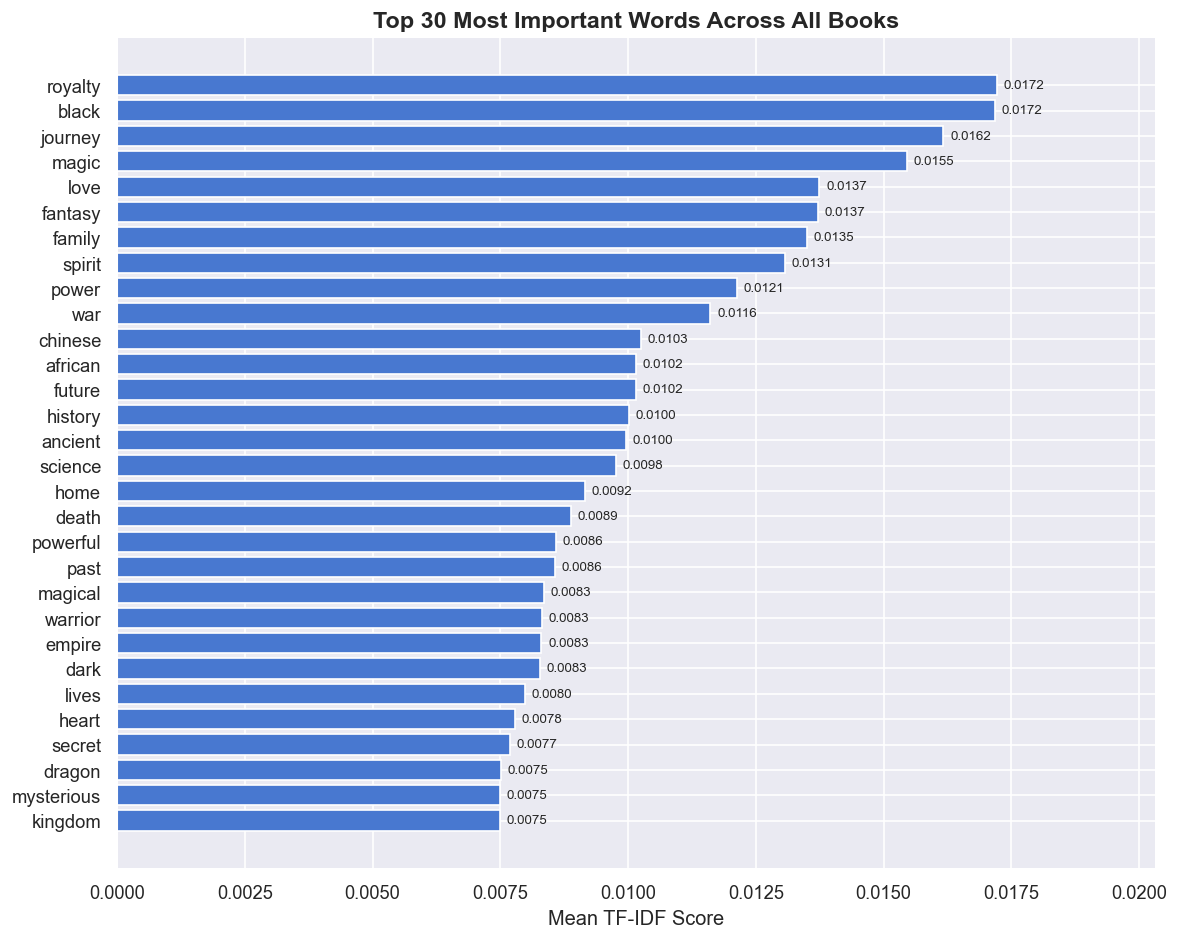

✅ Chart 9 saved


In [50]:
# ── Chart 9 — Top 30 words across the whole dataset ──────────────────────────
mean_scores = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
top_idx     = mean_scores.argsort()[-30:][::-1]
top_words   = feature_names[top_idx]
top_scores  = mean_scores[top_idx]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(top_words[::-1], top_scores[::-1],
               color=sns.color_palette("muted")[0], edgecolor="white")
ax.set_xlabel("Mean TF-IDF Score")
ax.set_title("Top 30 Most Important Words Across All Books", fontsize=14, fontweight="bold")
ax.bar_label(bars, labels=[f"{v:.4f}" for v in top_scores[::-1]], padding=4, fontsize=8)
ax.set_xlim(0, top_scores.max() * 1.18)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "09_top_tfidf_words.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 9 saved")

The numbers are the mean TF-IDF scores — let me explain what they actually mean in plain language.

Take "world" with 0.0227 — that means "world" is on average the most distinctive and frequently used word across your book descriptions. It appears a lot, and it's meaningful (not a filler word like "the").

The scores are small numbers because they're averaged across all 3,243 books. Most books won't use the word "world", so when you average the score across everyone the number stays small — but it's still the highest, meaning it wins compared to all other words.

**What the chart is actually telling you:**

The top words make a lot of sense for your dataset — "magic", "fantasy", "power", "war", "ancient" are exactly the themes you'd expect. "Chinese" and "African" showing up confirms your heritage tags are leaking into descriptions a bit, which is normal.

The words "book", "story", "fiction", "novel", "author" are a bit noisy though — those come from the description writing style ("this book follows...") rather than the actual themes. That's worth mentioning in your presentation as a known limitation. lets use a vectorizer and run it again.


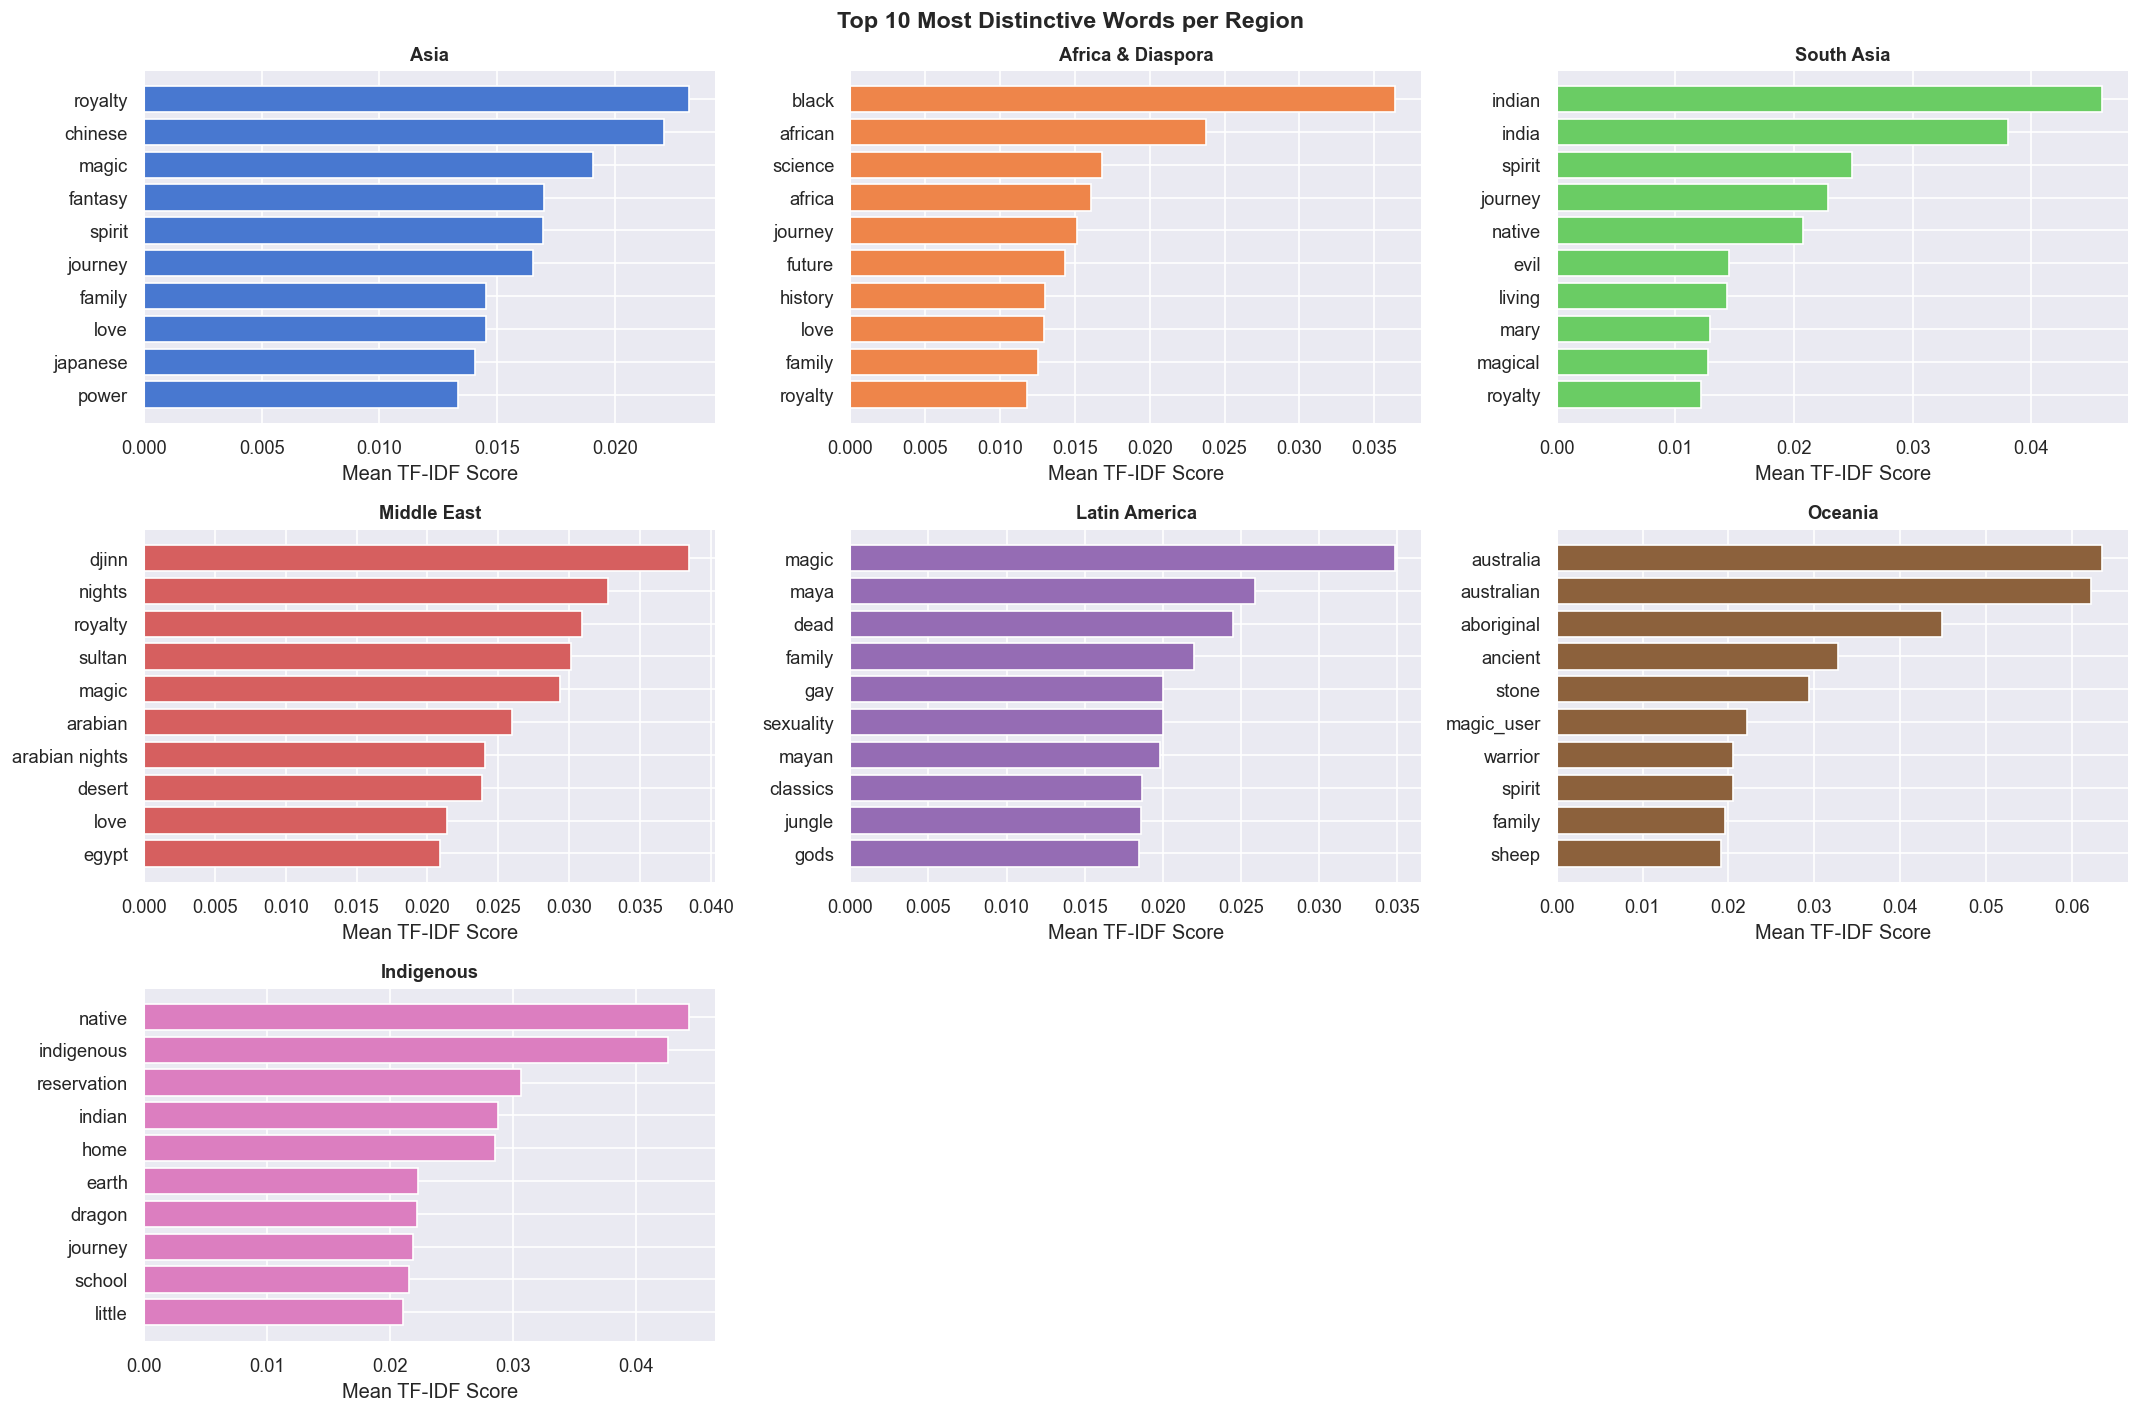

✅ Chart 10 saved


In [51]:
# ── Chart 10 — Top 10 words per region ───────────────────────────────────────
df_tfidf["region"] = df_tfidf["source_tag"].map(REGION_MAP).fillna("Other")
regions = [r for r in df_tfidf["region"].value_counts().index if r != "Other"]

n_cols = 3
n_rows = -(-len(regions) // n_cols)  # ceiling division
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, region in enumerate(regions):
    mask         = df_tfidf["region"] == region
    indices      = np.where(mask)[0]
    region_matrix = tfidf_matrix[indices]
    region_scores = np.asarray(region_matrix.mean(axis=0)).flatten()
    top10_idx     = region_scores.argsort()[-10:][::-1]

    axes[i].barh(feature_names[top10_idx][::-1], region_scores[top10_idx][::-1],
                 color=sns.color_palette("muted")[i % 8], edgecolor="white")
    axes[i].set_title(region, fontsize=11, fontweight="bold")
    axes[i].set_xlabel("Mean TF-IDF Score")

# Hide unused subplots
for j in range(len(regions), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Top 10 Most Distinctive Words per Region", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "10_tfidf_words_per_region.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 10 saved")

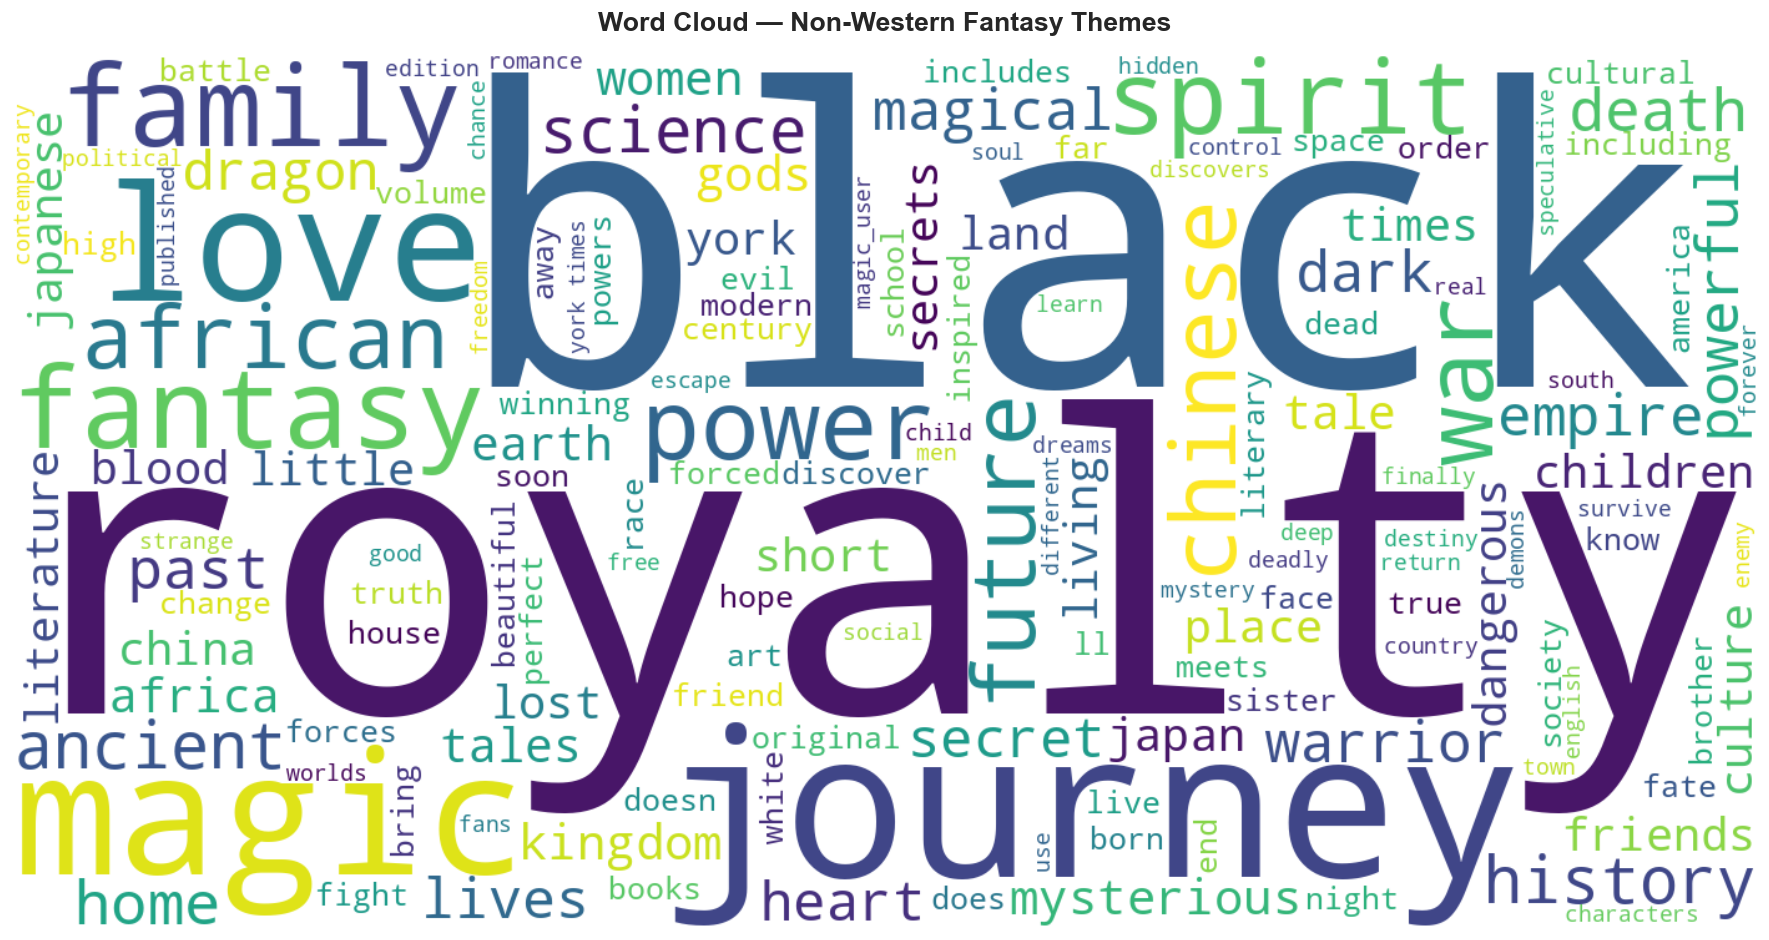

✅ Chart 11 saved


In [52]:
# ── Chart 11 — Word cloud ─────────────────────────────────────────────────────
from wordcloud import WordCloud

word_scores = dict(zip(feature_names, mean_scores))

wc = WordCloud(
    width=1400, height=700,
    background_color="white",
    colormap="viridis",
    max_words=150,
    prefer_horizontal=0.85,
)
wc.generate_from_frequencies(word_scores)

fig, ax = plt.subplots(figsize=(16, 8))
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")
ax.set_title("Word Cloud — Non-Western Fantasy Themes", fontsize=16, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "11_wordcloud.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 11 saved")

In [53]:
import umap
import hdbscan

In [54]:
print("Re-running UMAP with stopwords-cleaned matrix...")
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=20,
    min_dist=0.02,
    metric="cosine",
    random_state=42,
)
embedding = reducer.fit_transform(tfidf_matrix)

print("Running HDBSCAN clustering...")
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=25,
    min_samples=5,
    metric="euclidean",
)
labels = clusterer.fit_predict(embedding)
df_tfidf["cluster"] = labels

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise    = (labels == -1).sum()
print(f"Found {n_clusters} clusters, {n_noise} noise points")

# ── Quick cluster summary ─────────────────────────────────────────────────────
for cluster_id in sorted(set(labels)):
    if cluster_id == -1:
        continue
    cluster_books = df_tfidf[df_tfidf["cluster"] == cluster_id]
    top_regions   = cluster_books["region"].value_counts().head(3)
    print(f"\n── Cluster {cluster_id} ({len(cluster_books)} books) ──")
    print(f"  Regions: {top_regions.to_dict()}")
    print(f"  Sample titles:")
    for title in cluster_books["title"].sample(min(5, len(cluster_books)), random_state=42):
        print(f"    - {title}")

Re-running UMAP with stopwords-cleaned matrix...


c:\Users\Ready2Use\Documents\my-folder\Ironhack-week10\Book-recommendations\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Running HDBSCAN clustering...
Found 4 clusters, 49 noise points

── Cluster 0 (40 books) ──
  Regions: {'Africa & Diaspora': 39, 'Asia': 1}
  Sample titles:
    - Okoye to the People: A Black Panther Novel
    - Black Panther, Vol. 4: Avengers of the New World, Part One
    - Black Panther by Christopher Priest: The Complete Collection, Vol. 1
    - Black Panther, Vol. 9: The Intergalactic Empire of Wakanda, Part Four
    - Black Panther: Long Live the King

── Cluster 1 (33 books) ──
  Regions: {'Asia': 18, 'Africa & Diaspora': 13, 'Oceania': 1}
  Sample titles:
    - By the Sword
    - Hello, Moto
    - Thirteen orphans
    - Firebrand
    - Siren Queen

── Cluster 2 (30 books) ──
  Regions: {'Asia': 30}
  Sample titles:
    - Thousand Li : The Third Kingdom
    - The Fourth Fall (A Thousand Li, #11)
    - The Scum Villain's Self-Saving System -- Ren Zha Fanpai Zijiu Xitong Vol. 4
    - The Fox and the Dragon (Shrine and Shadow Book 1)
    - The First Step (A Thousand Li, #1)

── Clu

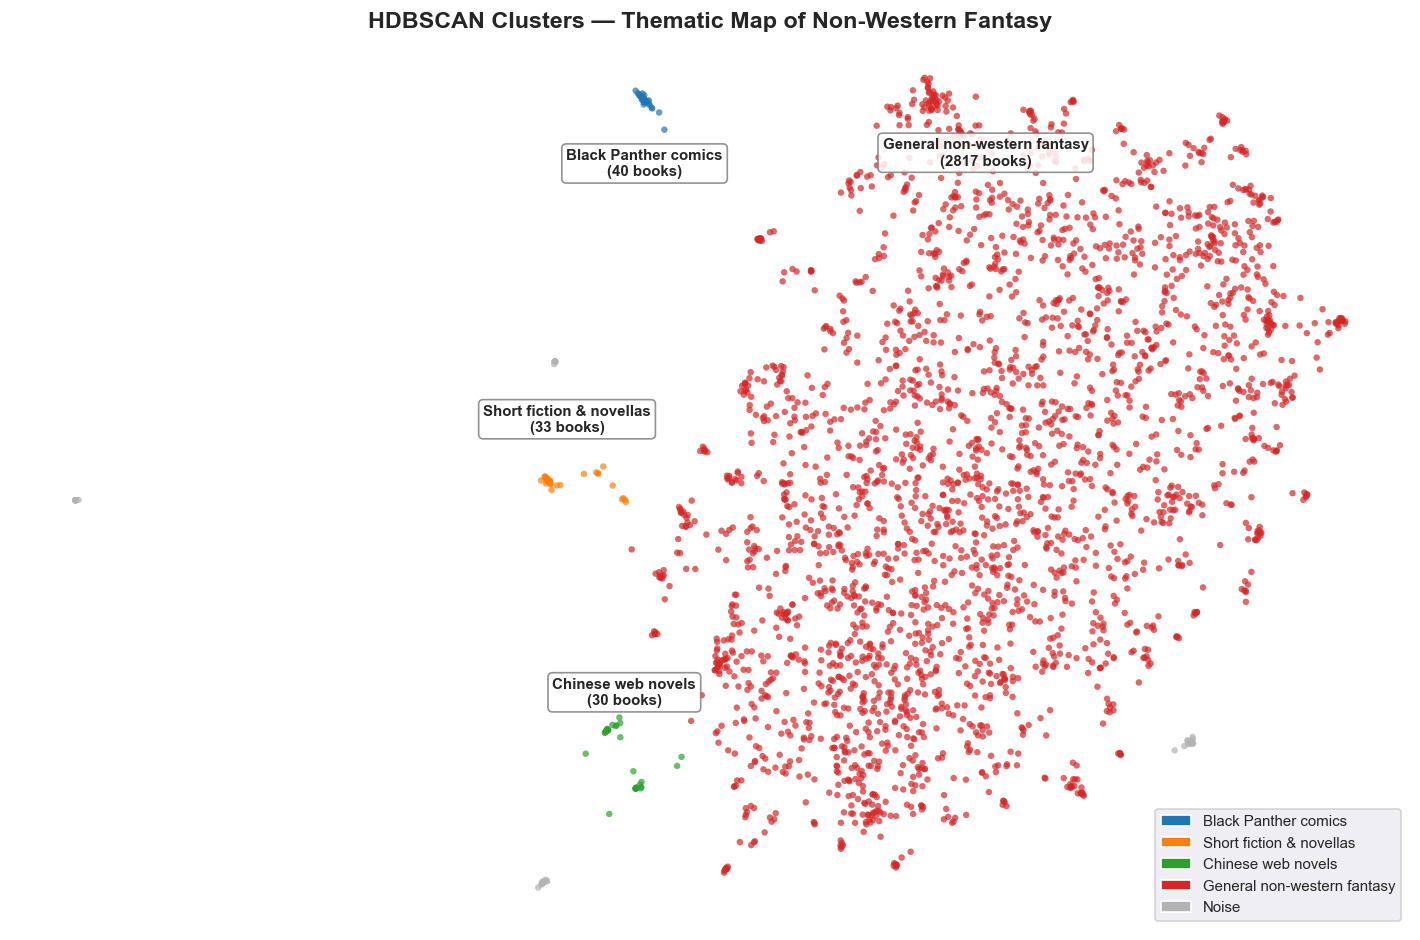

✅ Chart 12a saved


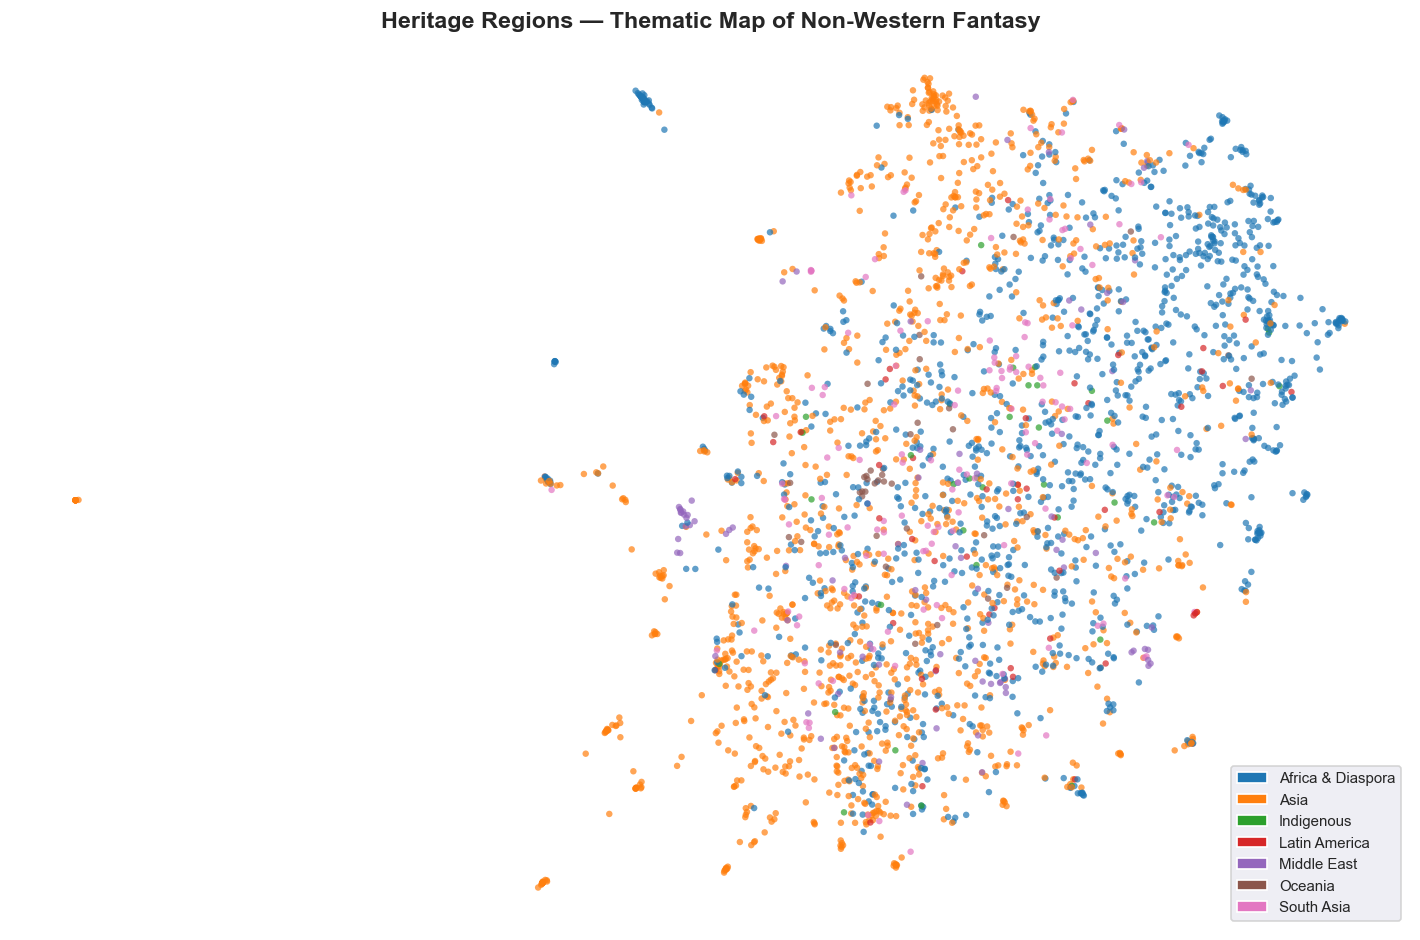

✅ Chart 12b saved


In [64]:
# ── Chart 12a — HDBSCAN Clusters (labels next to clusters) ───────────────────
fig, ax = plt.subplots(figsize=(12, 8))

cluster_labels = {
    0: "Black Panther comics",
    1: "Short fiction & novellas",
    2: "Chinese web novels",
    3: "General non-western fantasy",
}

# Manual offsets (x, y) relative to cluster centroid
label_offsets = {
    0: (0, -0.5),   # Black Panther — below
    1: (0,  0.5),   # Short fiction — above
    2: (0,  0.5),   # Chinese web novels — above
    3: (0,  2.5),   # General — above
}

palette = sns.color_palette("tab10", max(n_clusters, 1))
colors  = [palette[l % 10] if l >= 0 else (0.7, 0.7, 0.7) for l in labels]

ax.scatter(embedding[:, 0], embedding[:, 1],
           c=colors, s=15, alpha=0.7, linewidths=0)

for cluster_id in range(n_clusters):
    mask   = labels == cluster_id
    cx     = embedding[mask, 0].mean()
    cy     = embedding[mask, 1].mean()
    ox, oy = label_offsets[cluster_id]
    ax.text(cx + ox, cy + oy,
            f"{cluster_labels[cluster_id]}\n({mask.sum()} books)",
            fontsize=9, fontweight="bold", ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.85, ec="gray"))

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=palette[i], label=cluster_labels[i])
    for i in range(n_clusters)
] + [Patch(facecolor=(0.7, 0.7, 0.7), label="Noise")]

ax.legend(handles=legend_elements, loc="lower right", fontsize=9, framealpha=0.8)
ax.set_title("HDBSCAN Clusters — Thematic Map of Non-Western Fantasy",
             fontsize=14, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "12a_hdbscan_clusters.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 12a saved")


# ── Chart 12b — Heritage Regions ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))

region_list    = df_tfidf["region"].tolist()
unique_regions = sorted(set(region_list))
region_palette = dict(zip(unique_regions, sns.color_palette("tab10", len(unique_regions))))
region_colors  = [region_palette[r] for r in region_list]

ax.scatter(embedding[:, 0], embedding[:, 1],
           c=region_colors, s=15, alpha=0.7, linewidths=0)

legend_elements = [Patch(facecolor=region_palette[r], label=r) for r in unique_regions]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9, framealpha=0.8)
ax.set_title("Heritage Regions — Thematic Map of Non-Western Fantasy",
             fontsize=14, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "12b_heritage_regions.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 12b saved")

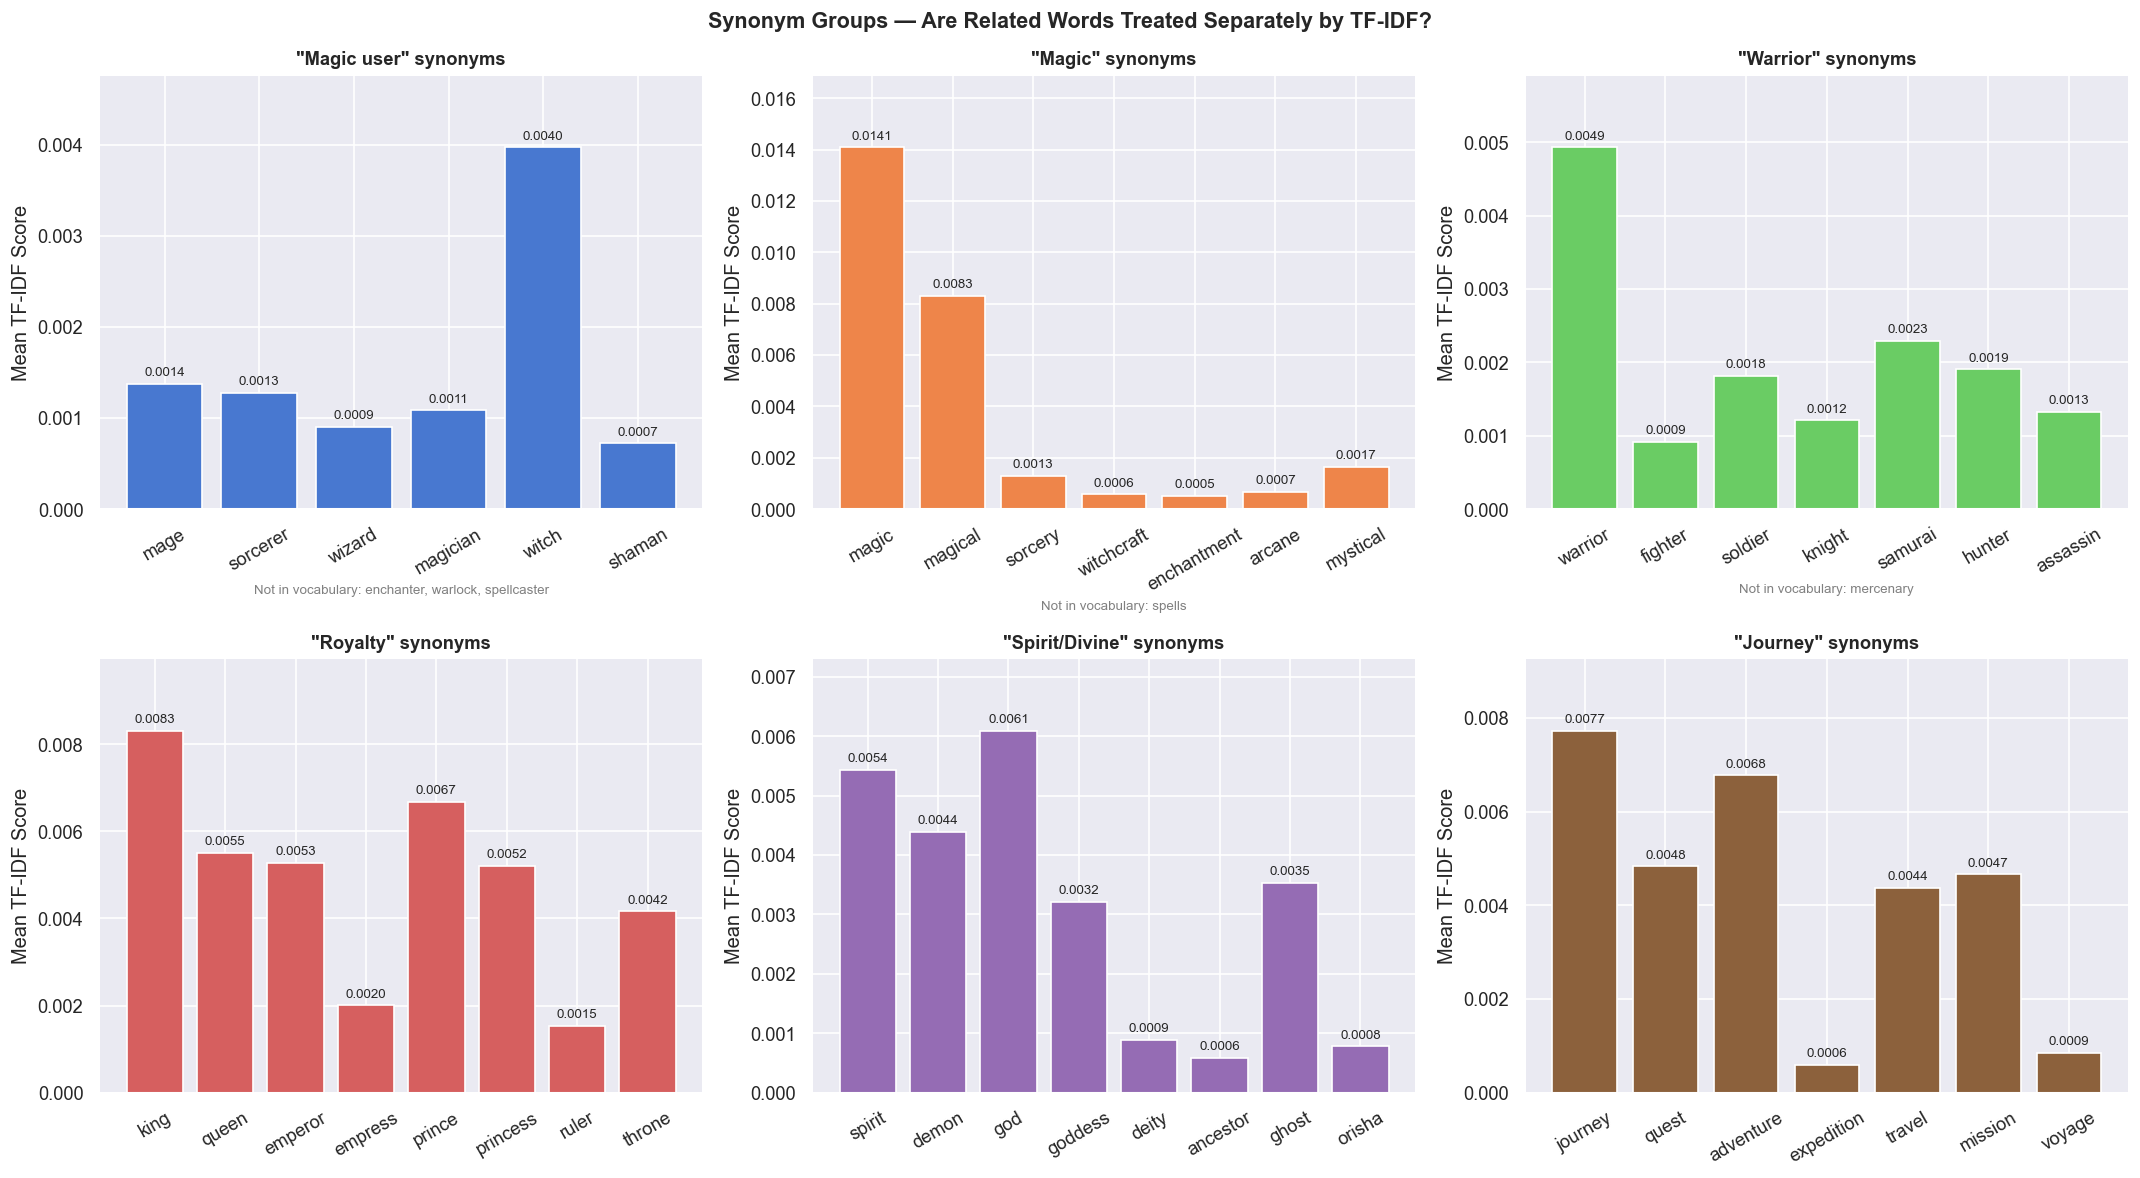

✅ Chart 13 saved

🎉 All TF-IDF visualizations complete!


In [45]:
# ── Chart 13 — Synonym / vocabulary analysis ─────────────────────────────────
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

SYNONYM_GROUPS = {
    "Magic user":    ["mage", "sorcerer", "wizard", "enchanter", "warlock",
                      "magician", "witch", "shaman", "spellcaster"],
    "Magic":         ["magic", "magical", "sorcery", "witchcraft", "enchantment",
                      "spells", "arcane", "mystical"],
    "Warrior":       ["warrior", "fighter", "soldier", "knight", "samurai",
                      "hunter", "assassin", "mercenary"],
    "Royalty":       ["king", "queen", "emperor", "empress", "prince",
                      "princess", "ruler", "throne"],
    "Spirit/Divine": ["spirit", "demon", "god", "goddess", "deity",
                      "ancestor", "ghost", "orisha"],
    "Journey":       ["journey", "quest", "adventure", "expedition",
                      "travel", "mission", "voyage"],
}

vocab_set        = set(feature_names)
word_score_dict  = dict(zip(feature_names, mean_scores))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (group_name, synonyms) in enumerate(SYNONYM_GROUPS.items()):
    present = [w for w in synonyms if w in vocab_set]
    absent  = [w for w in synonyms if w not in vocab_set]
    scores  = [word_score_dict[w] for w in present]

    colors_bar = [sns.color_palette("muted")[i % 8]] * len(present)
    bars = axes[i].bar(present, scores, color=colors_bar, edgecolor="white")
    axes[i].bar_label(bars, labels=[f"{v:.4f}" for v in scores], padding=3, fontsize=8)
    axes[i].set_title(f'"{group_name}" synonyms', fontsize=11, fontweight="bold")
    axes[i].set_ylabel("Mean TF-IDF Score")
    axes[i].tick_params(axis="x", rotation=30)
    axes[i].set_ylim(0, max(scores) * 1.2 if scores else 0.01)

    if absent:
        axes[i].set_xlabel(f"Not in vocabulary: {', '.join(absent)}",
                           fontsize=8, color="gray")

plt.suptitle("Synonym Groups — Are Related Words Treated Separately by TF-IDF?",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "13_synonym_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 13 saved")
print("\n🎉 All TF-IDF visualizations complete!")